In [5]:
import pandas as pd
from seaborn import lineplot
%load_ext autoreload
%autoreload 2
from visualisierungen import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [6]:
df = pd.read_csv("../data/processed/df_with_positions.csv")
print(df.head())

   anr       datum  legisjahr             rechtsform_name  \
0  1.0  1848-09-12  1848-1851  Obligatorisches Referendum   
1  2.0  1866-01-14  1863-1866  Obligatorisches Referendum   
2  3.0  1866-01-14  1863-1866  Obligatorisches Referendum   
3  4.0  1866-01-14  1863-1866  Obligatorisches Referendum   
4  5.0  1866-01-14  1863-1866  Obligatorisches Referendum   

                                        titel_kurz_d  anzahl  beteiligung  \
0  Bundesverfassung der schweizerischen Eidgenoss...       1          NaN   
1                                   Mass und Gewicht       9          NaN   
2  Gleichstellung der Juden und Naturalisierten m...       9          NaN   
3  Stimmrecht der Niedergelassenen in Gemeindeang...       9          NaN   
4  Besteuerung und zivilrechtliche Verhältnisse d...       9          NaN   

   annahme  volkja-proz  berecht  ...  zustimmung_p-kdk  zustimmung_p-kkjpd  \
0      1.0        72.83      NaN  ...               NaN                 NaN   
1      0.0  

In [7]:
df["jahrzehnt"] = df["jahrzehnt"].astype(str)

# Alle Abstimmungen

### Anzahl Abstimmungen über Zeit

In [18]:
frames = []
for gruppe, cols in gruppen.items():
    empfehlungen = df.groupby('jahrzehnt')[cols].count().sum(axis=1)
    gesamt = df.groupby('jahrzehnt').size()
    max_empfehlungen = gesamt * len(cols)  # maximal mögliche Empfehlungen
    temp = (empfehlungen / max_empfehlungen).reset_index(name='anteil')
    temp['gruppe'] = gruppe
    frames.append(temp)

numbers_vote = pd.concat(frames, ignore_index=True)

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:63: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.barplot(data=data, x=x, y=y, hue=hue,


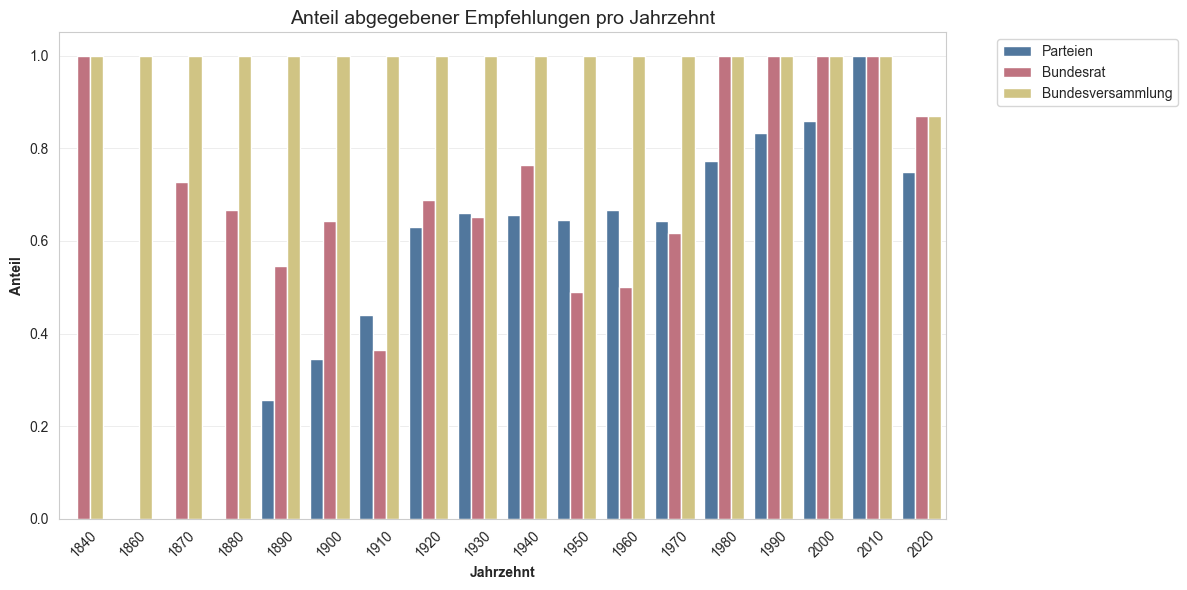

In [20]:
balkendiagramm(numbers_vote, x='jahrzehnt', y='anteil', hue='gruppe',
               titel="Anteil abgegebener Empfehlungen pro Jahrzehnt",
               xlabel="Jahrzehnt", ylabel="Anteil",
               figsize=(12, 6), rotation=45)

### Anzahl Abstimmungsempfehlungen

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=data, x=x, y=y, hue=hue,
/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:63: UserWarning: 
The palette list has fewer values (6) than needed (18) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=data, x=x, y=y, hue=hue,


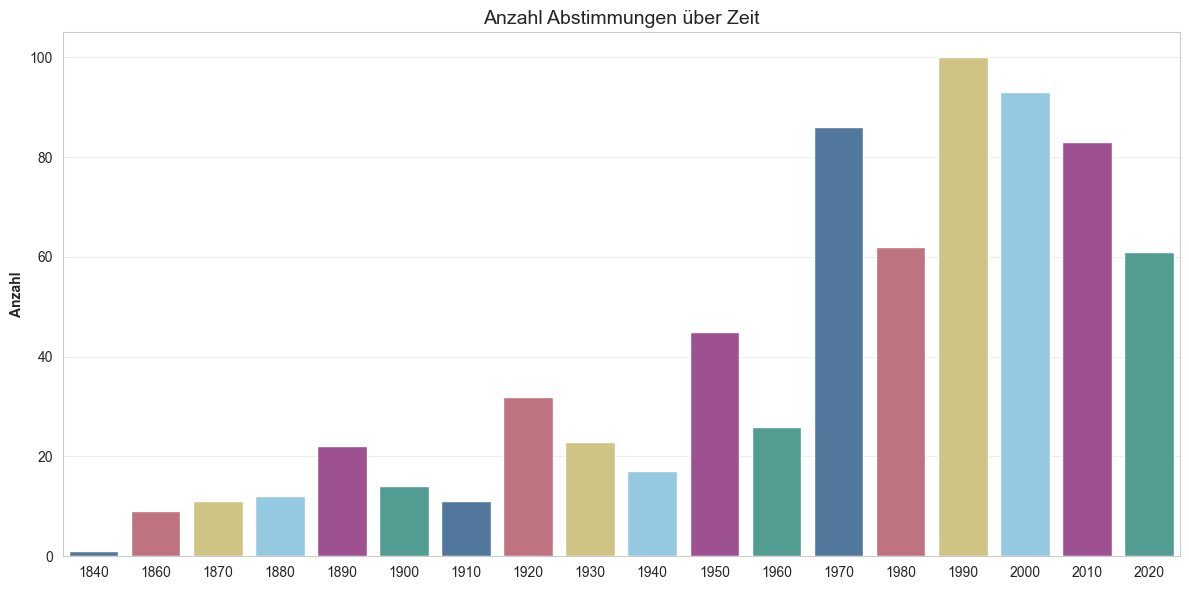

In [10]:
numbers_vote = df.groupby(['jahrzehnt']).size().reset_index(name='anzahl')
balkendiagramm(numbers_vote, x='jahrzehnt', y='anzahl', xlabel="", ylabel="Anzahl", titel="Anzahl Abstimmungen über Zeit",
                  ylim=None, palette=None, figsize=(12,6),
                  rotation=0, order=None, annotate=False, fmt=".0f")

# Postion-Bundesrat vs. Zustimmung

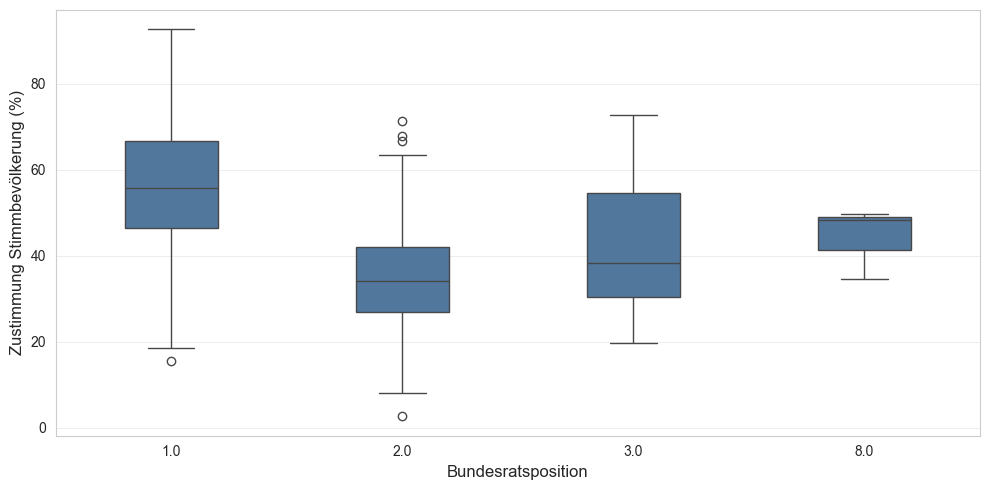

In [11]:
boxplot(df, df["br-pos"], df["volkja-proz"], titel="", xlabel="Bundesratsposition", ylabel="Zustimmung Stimmbevölkerung (%)", farbe=None)


# Zeitliche Dimension

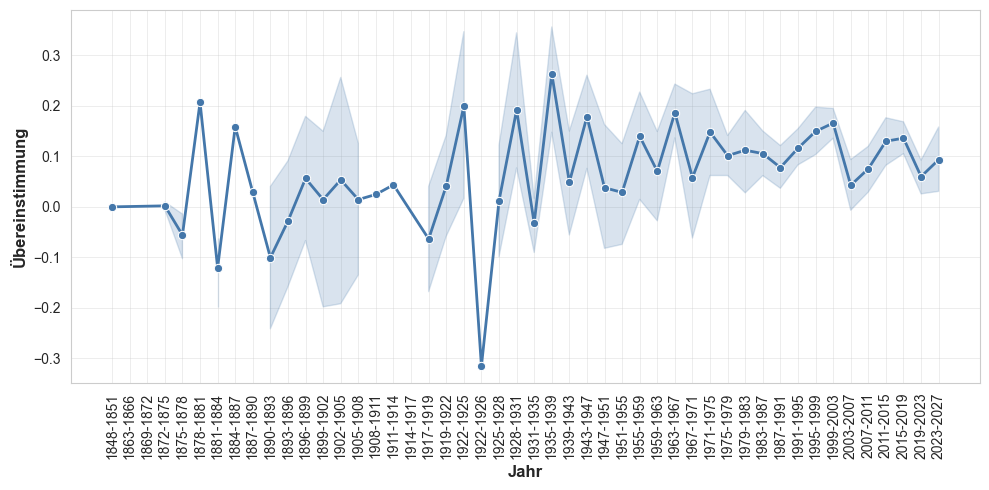

In [12]:
liniendiagramm(df, x="legisjahr", y="zustimmung_br-pos",
               xlabel="Jahr", ylabel="Übereinstimmung", rotation=90, errorbar=True)

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:322: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


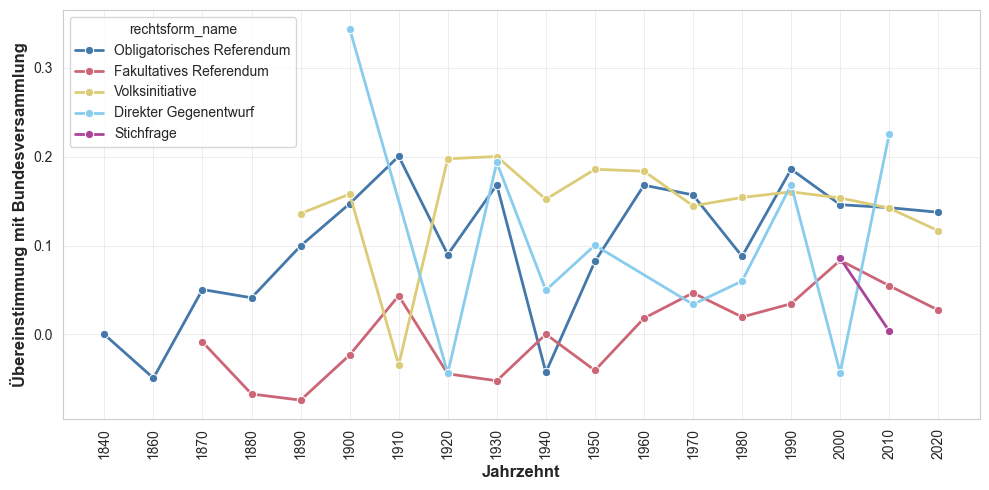

In [13]:
liniendiagramm(df, x="jahrzehnt", y="zustimmung_bv-pos",
               xlabel="Jahrzehnt", ylabel="Übereinstimmung mit Bundesversammlung", rotation=90, hue="rechtsform_name", errorbar=False)

/Users/charlotteschwegler/Desktop/Repos/Demokratie Challenge/notebooks/visualisierungen.py:322: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.lineplot(


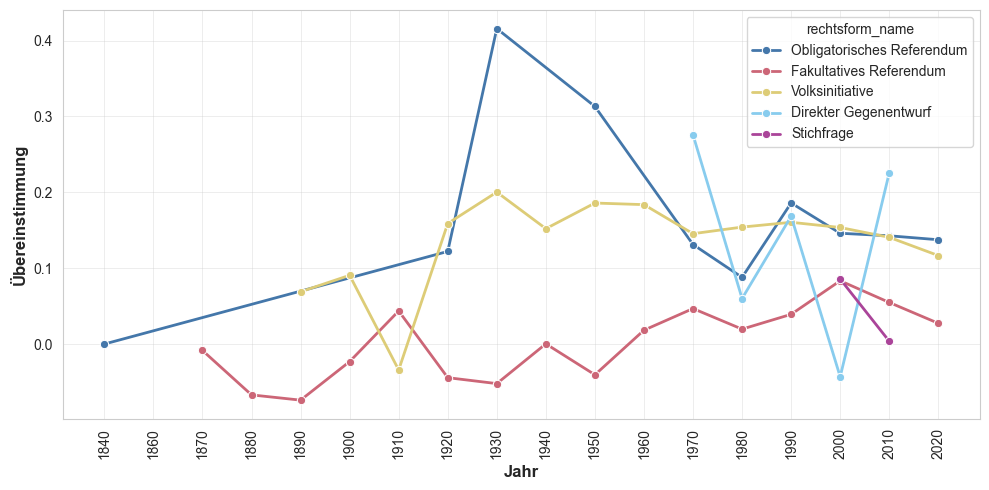

In [14]:
liniendiagramm(df, x="jahrzehnt", y="zustimmung_br-pos",
               xlabel="Jahr", ylabel="Übereinstimmung", rotation=90, hue="rechtsform_name", errorbar=None)

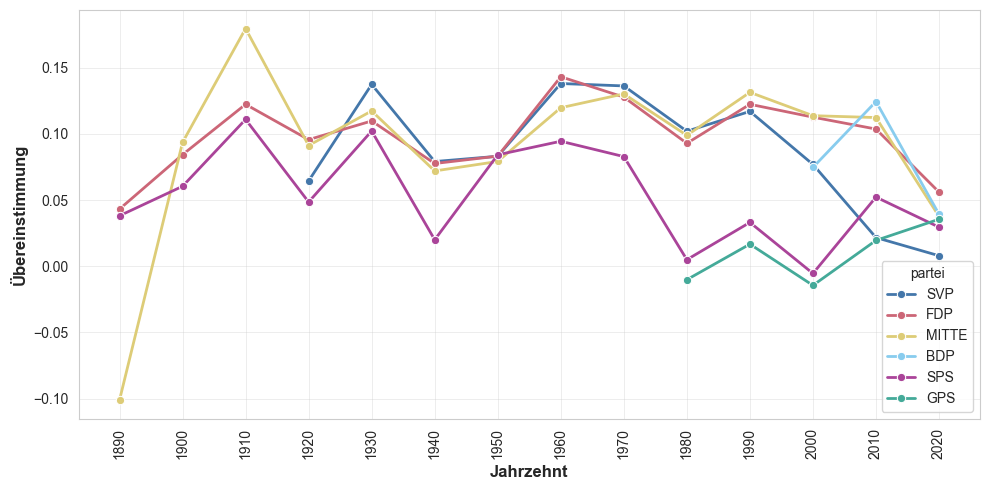

([<matplotlib.axis.XTick at 0x1152e3610>,
 [Text(0, 0, '1840'),
  Text(1, 0, '1860'),
  Text(2, 0, '1870'),
  Text(3, 0, '1880'),
  Text(4, 0, '1890'),
  Text(5, 0, '1900'),
  Text(6, 0, '1910'),
  Text(7, 0, '1920'),
  Text(8, 0, '1930'),
  Text(9, 0, '1940'),
  Text(10, 0, '1950'),
  Text(11, 0, '1960'),
  Text(12, 0, '1970'),
  Text(13, 0, '1980'),
  Text(14, 0, '1990'),
  Text(15, 0, '2000'),
  Text(16, 0, '2010'),
  Text(17, 0, '2020')])

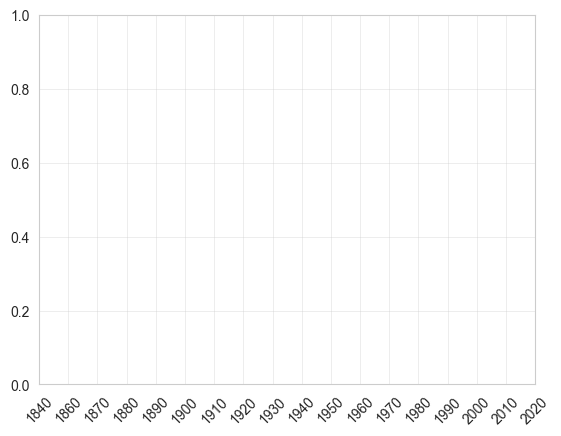

In [15]:
partei_cols = ["zustimmung_p-svp", "zustimmung_p-fdp", "zustimmung_p-mitte","zustimmung_p-bdp", "zustimmung_p-sps", "zustimmung_p-gps"]

df_long = df[["jahrzehnt"] + partei_cols].melt(
    id_vars="jahrzehnt", var_name="partei", value_name="zustimmung")
df_long['partei'] = df_long['partei'].str.replace('zustimmung_p-', '').str.upper()

liniendiagramm(df_long, x="jahrzehnt", y="zustimmung", hue="partei",
               xlabel="Jahrzehnt", ylabel="Übereinstimmung", rotation=90)
plt.xticks(ticks=range(len(df_long['jahrzehnt'].unique())),
           labels=sorted(df_long['jahrzehnt'].unique()), rotation=45)